In [1]:
# Required Libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import MissingIndicator,SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report, average_precision_score, precision_recall_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv("Fraud")  # Calling a Data Set.

In [5]:
dataset

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


# Data Understanding

In [7]:
df = pd.DataFrame(dataset)

In [7]:
df.shape

(6362620, 11)

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [15]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [25]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [27]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

# Memory Optimization.

In [11]:
df.memory_usage(deep=True).sum() / 1e6   # Before.

1523.125282

In [13]:
for col in df.select_dtypes(include='int'):
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include='float'):
    df[col] = pd.to_numeric(df[col], downcast='float')

In [15]:
df.memory_usage(deep=True).sum() / 1e6    # After.

1395.872882

# 1 Data Cleaning (Missing values, Outliers, Multicollinearity).

In [13]:
# In this Dataset the receiver's name whose name starts with M have no data in before and after receiving a money, 
# it does not mean
# that Merchant had no money , so it's simply indicating the missing value.
# In short oldbalanceDest and newbalanceDest are zero doesn't have zero money --> they indicates the missing values

In [7]:
df['dest_balance_missing'] = (df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0)     # Instead of dropping , we preserve it because missing 
# values indicates strong detection.

In [9]:
df['dest_is_merchant'] = df['nameDest'].str.startswith('M').astype(int)  # creating a column for merchant for indication merchant account is empty.

In [19]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,dest_balance_missing,dest_is_merchant
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,True,1
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,True,1
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,True,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,False,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,False,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,True,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,False,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,True,0


In [23]:
# Outliers.
%matplotlib inline

In [27]:
df1 = df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']].skew() # measuring the skewness.
df1

amount            30.993949
oldbalanceOrg      5.249136
newbalanceOrig     5.176884
oldbalanceDest    19.921758
newbalanceDest    19.352302
dtype: float64

In [ ]:
# Since the columns in below are right skewed --> we apply log transformation.

In [11]:
import numpy as np

cols = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
for col in cols:
    df[col + '_log'] = np.log1p(df[col])

In [35]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,dest_balance_missing,dest_is_merchant,amount_log,oldbalanceOrg_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,True,1,9.194276,12.044359,11.984786,0.000000,0.000000
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,True,1,7.531166,9.964112,9.872292,0.000000,0.000000
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,True,0,5.204007,5.204007,0.000000,0.000000,0.000000
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,False,0,5.204007,5.204007,0.000000,9.960954,0.000000
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,True,1,9.364703,10.634773,10.305174,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,False,0,12.735768,12.735768,0.000000,0.000000,12.735768
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,True,0,15.657870,15.657870,0.000000,0.000000,0.000000
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,False,0,15.657870,15.657870,0.000000,11.134441,15.668663
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,True,0,13.652996,13.652996,0.000000,0.000000,0.000000


In [37]:
df[['amount_log',	'oldbalanceOrg_log'	,'newbalanceOrig_log',	'oldbalanceDest_log',	'newbalanceDest_log']].skew()

amount_log           -0.555018
oldbalanceOrg_log    -0.259723
newbalanceOrig_log    0.440148
oldbalanceDest_log   -0.213261
newbalanceDest_log   -0.386937
dtype: float64

In [39]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,dest_balance_missing,dest_is_merchant,amount_log,oldbalanceOrg_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,True,1,9.194276,12.044359,11.984786,0.000000,0.000000
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,True,1,7.531166,9.964112,9.872292,0.000000,0.000000
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,True,0,5.204007,5.204007,0.000000,0.000000,0.000000
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,False,0,5.204007,5.204007,0.000000,9.960954,0.000000
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,True,1,9.364703,10.634773,10.305174,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,False,0,12.735768,12.735768,0.000000,0.000000,12.735768
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,True,0,15.657870,15.657870,0.000000,0.000000,0.000000
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,False,0,15.657870,15.657870,0.000000,11.134441,15.668663
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,True,0,13.652996,13.652996,0.000000,0.000000,0.000000


In [28]:
# No use of these columns given below.

In [13]:
df4 = df.drop(columns = ['amount','oldbalanceOrg'	,'newbalanceOrig' ,'oldbalanceDest',	'newbalanceDest'])
df4

,step,type,nameOrig,nameDest,isFraud,isFlaggedFraud,dest_balance_missing,dest_is_merchant,amount_log,oldbalanceOrg_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log
0,1,PAYMENT,C1231006815,M1979787155,0,0,True,1,9.194276,12.044359,11.984786,0.000000,0.000000
1,1,PAYMENT,C1666544295,M2044282225,0,0,True,1,7.531166,9.964112,9.872292,0.000000,0.000000
2,1,TRANSFER,C1305486145,C553264065,1,0,True,0,5.204007,5.204007,0.000000,0.000000,0.000000
3,1,CASH_OUT,C840083671,C38997010,1,0,False,0,5.204007,5.204007,0.000000,9.960954,0.000000
4,1,PAYMENT,C2048537720,M1230701703,0,0,True,1,9.364703,10.634773,10.305174,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,C786484425,C776919290,1,0,False,0,12.735768,12.735768,0.000000,0.000000,12.735768
6362616,743,TRANSFER,C1529008245,C1881841831,1,0,True,0,15.657870,15.657870,0.000000,0.000000,0.000000
6362617,743,CASH_OUT,C1162922333,C1365125890,1,0,False,0,15.657870,15.657870,0.000000,11.134441,15.668663
6362618,743,TRANSFER,C1685995037,C2080388513,1,0,True,0,13.652996,13.652996,0.000000,0.000000,0.000000


In [ ]:
# Here, it is checking the multicollinearity of dataset columns by using two methods: 1) correlation 2) Varinace Inflation factor(VIF).
# Those having strong correlation and VIF > 5 or 10 should be remove to decrease multicollinearity of dataset.

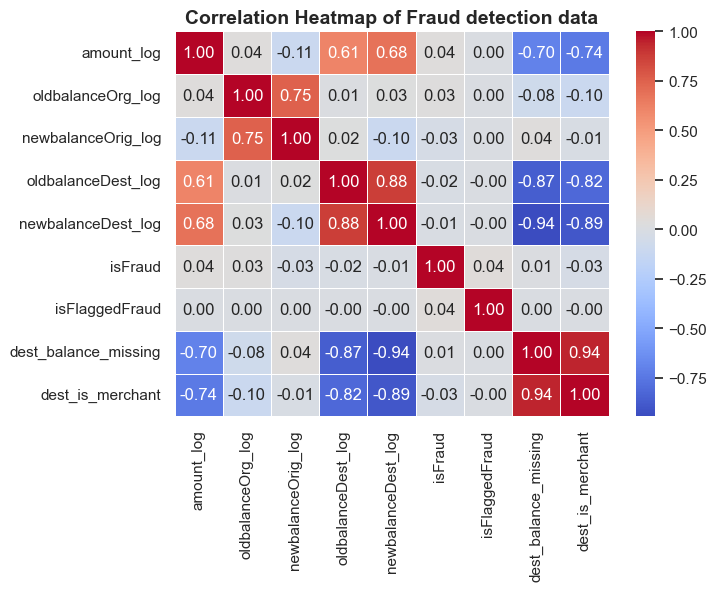

In [59]:
sns.set(style = "whitegrid", palette = "coolwarm")
df3 = df1[['amount_log','oldbalanceOrg_log',	'newbalanceOrig_log',	'oldbalanceDest_log'	,'newbalanceDest_log','isFraud'	,'isFlaggedFraud',	'dest_balance_missing'	,'dest_is_merchant']]
corr_matrix = df1.corr()

plt.figure(figsize = (7,5))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f" , linewidth = 0.5)
plt.title("Correlation Heatmap of Fraud detection data", fontsize = 14, weight = 'bold')
plt.show()

In [17]:
from sklearn.preprocessing import OneHotEncoder

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform
encoded = encoder.fit_transform(df4[['type']])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['type']))

# Merge back
df5 = df4.drop('type', axis=1)
df6 = pd.concat([df5, encoded_df], axis=1)
df6

,step,nameOrig,nameDest,isFraud,isFlaggedFraud,dest_balance_missing,dest_is_merchant,amount_log,oldbalanceOrg_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,C1231006815,M1979787155,0,0,True,1,9.194276,12.044359,11.984786,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0
1,1,C1666544295,M2044282225,0,0,True,1,7.531166,9.964112,9.872292,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0
2,1,C1305486145,C553264065,1,0,True,0,5.204007,5.204007,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0
3,1,C840083671,C38997010,1,0,False,0,5.204007,5.204007,0.000000,9.960954,0.000000,0.0,1.0,0.0,0.0,0.0
4,1,C2048537720,M1230701703,0,0,True,1,9.364703,10.634773,10.305174,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,C786484425,C776919290,1,0,False,0,12.735768,12.735768,0.000000,0.000000,12.735768,0.0,1.0,0.0,0.0,0.0
6362616,743,C1529008245,C1881841831,1,0,True,0,15.657870,15.657870,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0
6362617,743,C1162922333,C1365125890,1,0,False,0,15.657870,15.657870,0.000000,11.134441,15.668663,0.0,1.0,0.0,0.0,0.0
6362618,743,C1685995037,C2080388513,1,0,True,0,13.652996,13.652996,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0


# 3) Fraud Detection Model (Detailed)

In [43]:
# By dropping some more features...our dataset looks like given below , since their is no use of the name columns for what our aim is.
# We used an XGBoost Classifier, because:

# Handles large-scale, imbalanced data well.

# Captures non-linear relationships.
# Variable Selection

# We selected variables based on:

# Business logic (transaction amount, balances, type)

# Correlation analysis

# Feature importance from model

# Avoiding data leakage (excluded isFlaggedFraud from predictors
# Final important variables:

# amount
# type

# oldbalanceOrg, newbalanceOrig

# oldbalanceDest, newbalanceDest

# dest_balance_missing

# balance_diff

In [31]:
X = df6.drop(['isFraud','nameOrig','nameDest'],axis = 1)
y = df6['isFraud']

In [ ]:
# Model Training.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2, random_state = 42, stratify=y)

In [ ]:
# Baseline Line Model

In [47]:
from sklearn.linear_model import SGDClassifier

model = SGDClassifier(
    loss='log_loss',        # Logistic Regression
    penalty='l2',           # Regularization.
    alpha=0.0001,           # Regularization strength (default & safe)
    learning_rate='optimal',
    max_iter=2000,          # Enough for convergence on large data
    tol=1e-3,               # Stops early if converged.
    class_weight='balanced',# Handles class imbalance
    n_jobs=-1,              # Use all CPU cores
    random_state=41
)


# 4) Model Performance Evaluation
# We used multiple metrics due to class imbalance:

In [ ]:
# Metric     Why Used                        

# Recall     Catch as much fraud as possible 
# Precision  Avoid too many false alarms     
# PR-AUC     Best metric for rare fraud      
# ROC-AUC    Measures ranking quality      

In [49]:
model.fit(X_train , y_train)

y_pred = model.predict(X_test)
print("Accuracy Score", accuracy_score(y_test,y_pred))
print("ROC-AUC-SCORE", roc_auc_score(y_test, y_pred))

Accuracy Score 0.9753096994634286
ROC-AUC-SCORE 0.9219904558058568


In [51]:
y_proba = model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_proba)

print("PR-AUC:", pr_auc)
print("Recall Score", recall_score(y_test, y_pred))

PR-AUC: 0.04715164123699603
Recall Score 0.8685331710286062


In [39]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [35]:
from xgboost import XGBClassifier
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

In [37]:
model1 = XGBClassifier(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='aucpr',
    tree_method='hist',          
    max_bin=256,
    min_child_weight = 5,
    scale_pos_weight=scale_pos_weight,
    n_jobs = 1,
    gamma = 0.5,
    reg_lambda = 1.5,
    random_state=41
)    

In [39]:
model1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=256, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=800,
              n_jobs=1, num_parallel_tree=None, ...)

In [45]:
# Checking Wheather data is balanced or imbalanced.

In [47]:
df_baseline['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [41]:
y_pred1 = model1.predict(X_test)
print("Accuracy Score", accuracy_score(y_test,y_pred1))
print("ROC-AUC-SCORE", roc_auc_score(y_test, y_pred1))

Accuracy Score 0.9973305022144966
ROC-AUC-SCORE 0.9947124623771673


In [43]:
print("Recall Score", recall_score(y_test, y_pred1))
y_proba = model1.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_proba)
print("PR-AUC:", pr_auc)     # Since Data is umbalanced type so, we can take a precision - recall - auc metric.

Recall Score 0.9920876445526476
PR-AUC: 0.963093013953797


In [ ]:
# Since Recall, PR-AUC and ROC-AUC score are very important metrics . According to our aim, we have to acheive 
# 98 --> percent recall, 98 percantage --> ROC-AUC and 84 percent --> PR-AUC(Precision-Recall -AUC).

In [47]:
# Plotting Precision - Recall Curve

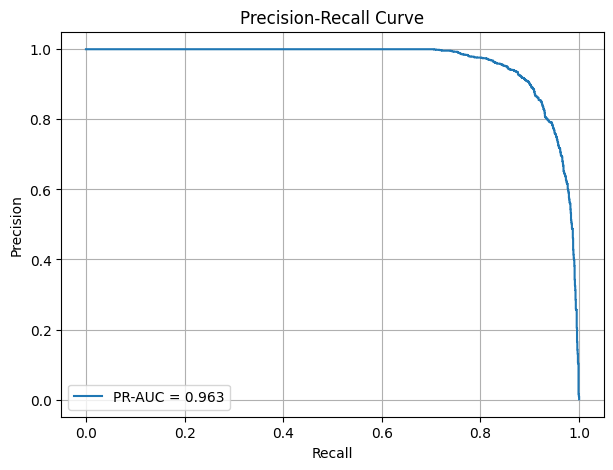

In [45]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize = (7,5))
plt.plot(recall, precision, label = f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

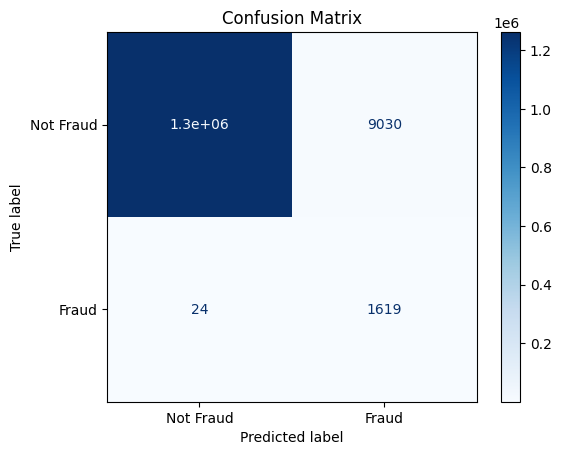

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = (y_proba >= 0.5).astype(int)  # You can change threshold

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

️ Key Factors Predicting Fraud

# 5) Key Factors Predicting Fraud

In [ ]:
️# Key Factors Predicting Fraud

# Top fraud indicators:

# High transaction amount

# TRANSFER and CASH_OUT transaction types

# Zero destination balance before transaction

# Full account balance drained

# Balance mismatch (old − new ≠ amount)

# 6) Do These Factors Make Sense?

In [ ]:
#Fraudsters:

#Drain accounts completely.

#Transfer money to newly created or empty accounts.

#Prefer TRANSFER → CASH_OUT patterns.

#Create balance inconsistencies due to system manipulation.

# 7) Prevention Strategies for Infrastructure Update

In [ ]:
#Prevention Strategies for Infrastructure Update
 #Technical Controls

#Real-time fraud scoring on:

#Large transfers

#Sudden balance drops

#Zero-balance destination accounts

#Threshold-based transaction blocking.

#Multi-factor authentication for high-risk transactions.

#Policy Controls

#Daily transfer limits.

#Delayed settlement for suspicious transactions.

#Auto-freeze on repeated high-risk behavior.

# 8) How to Measure If Prevention Works

In [ ]:
# Measure                 Goal              

# Fraud loss per day       Decrease .       
# Fraud detection recall   Increase.        
# False positive rate      Stable or lower. 
# Customer complaints      Decrease.        

#Also:

#Monitor PR-AUC over time.

#Perform A/B testing on fraud rules.

#Audit blocked vs confirmed fraud cases.